In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
# Download historical stock data
ticker = 'HDFCBANK.NS'
data = yf.download(ticker, start='2020-01-01', end='2024-07-24')

[*********************100%%**********************]  1 of 1 completed


In [5]:
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-01,1276.099976,1280.000000,1270.599976,1278.599976,1227.428589,1836849
2020-01-02,1279.000000,1288.000000,1279.000000,1286.750000,1235.252441,3068583
2020-01-03,1282.199951,1285.000000,1263.599976,1268.400024,1217.636841,5427775
2020-01-06,1260.000000,1261.800049,1236.000000,1240.949951,1191.285400,5445093
2020-01-07,1258.900024,1271.449951,1252.250000,1260.599976,1210.148926,7362247
...,...,...,...,...,...,...
2024-07-16,1620.750000,1627.000000,1616.800049,1619.750000,1619.750000,14475162
2024-07-18,1608.000000,1623.949951,1599.150024,1614.800049,1614.800049,16858532
2024-07-19,1616.000000,1623.000000,1603.500000,1607.300049,1607.300049,13001076


In [6]:
# Calculate RSI
def calculate_rsi(data, window = 14):
    delta = data['Close'].diff()
    gain = (delta.where(delta>0,0)).rolling(window = window).mean()
    loss = (-delta.where(delta<0,0)).rolling(window = window).mean()
    rs = gain/loss
    rsi = 100 - (100/(1+rs))
    return rsi

In [7]:
data['RSI'] = calculate_rsi(data)

In [8]:
# Implement the strategy
def implement_rsi_strategy(data):
    buy_signal = []
    sell_signal = []
    position = False
    for i in range(len(data)):
        if data["RSI"].iloc[i]>30 and position==False:
            buy_signal.append(data['Close'].iloc[i])
            sell_signal.append(np.nan)
            position = True
        elif data['RSI'].iloc[i] > 70 and position==True:
            buy_signal.append(np.nan)
            sell_signal.append(data['Close'].iloc[i])
            position = False
        else:
            buy_signal.append(np.nan)
            sell_signal.append(np.nan)

    return buy_signal, sell_signal

In [9]:
data["Buy_price_signal"], data["Sell_price_signal"] = implement_rsi_strategy(data)

In [20]:
import numpy as np

# Filtering not equal to Nan values in buy price signal column

data1 = data[~data['Buy_price_signal'].isna()]
data1

,Open,High,Low,Close,Adj Close,Volume,RSI,Buy_price_signal,Sell_price_signal
Date,,,,,,,,,
2020-01-20,1304.849976,1304.849976,1252.500000,1254.900024,1204.677124,11089225,42.126262,1254.900024,NaN
2020-06-08,1060.000000,1066.650024,1006.400024,1015.900024,975.242310,24906332,79.037754,1015.900024,NaN
2020-06-10,990.000000,999.849976,978.200012,991.849976,952.154724,18248865,71.779539,991.849976,NaN
2020-06-15,968.000000,974.000000,943.000000,949.849976,911.835632,16004968,64.207605,949.849976,NaN
2020-07-02,1090.300049,1111.250000,1085.199951,1089.400024,1045.800781,18477248,71.206977,1089.400024,NaN
...,...,...,...,...,...,...,...,...,...
2024-06-20,1669.800049,1681.449951,1652.000000,1669.349976,1669.349976,20704371,71.656872,1669.349976,NaN
2024-06-26,1707.949951,1710.900024,1691.099976,1701.500000,1701.500000,23798333,87.294512,1701.500000,NaN
2024-06-28,1697.599976,1706.599976,1679.000000,1683.800049,1683.800049,13238023,78.054413,1683.800049,NaN


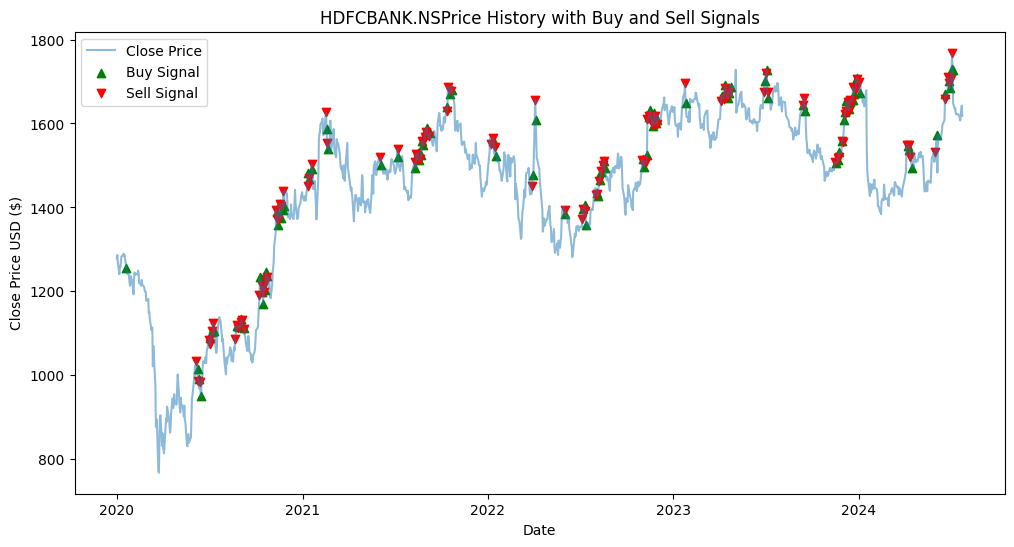

In [24]:
# Plot the results
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.scatter(data.index, data['Buy_price_signal'], label='Buy Signal', marker='^', color='green', alpha=1)
plt.scatter(data.index, data['Sell_price_signal'], label='Sell Signal', marker='v', color='red', alpha=1)
plt.title(f'{ticker} Price History with Buy and Sell Signals')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.legend(loc='best')
plt.show()

AttributeError: Line2D.set() got an unexpected keyword argument 'lable'

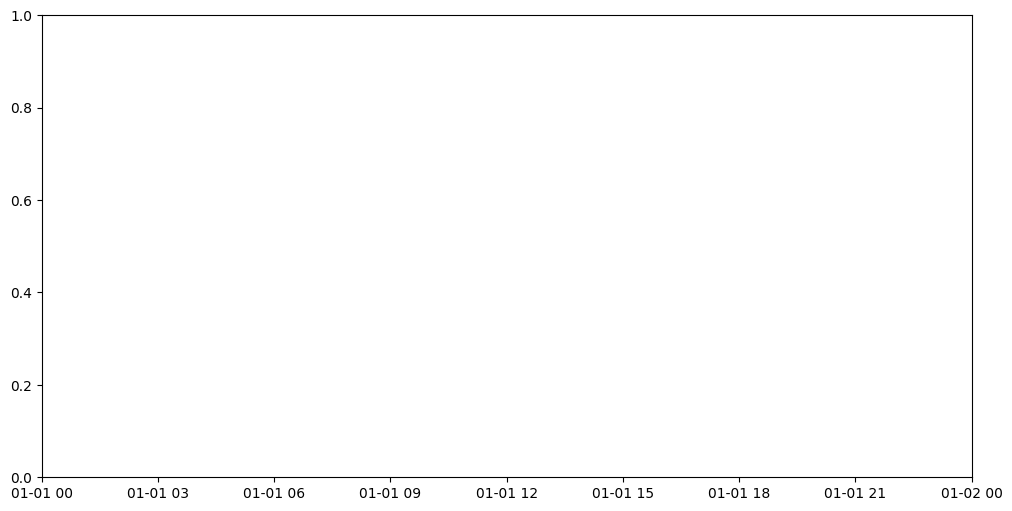

In [21]:
# Plot the results

plt.figure(figsize =(12,6))
plt.plot(data['Close'],lable = 'Close Price', alpha = 0.5)
plt.scatter(data.index, data['Buy_Signal_Price'], label = 'Buy', marker = '^', color = 'green', alpha=1)
plt.scatter(data.index, data['Sell_Signal_Price'], label = 'Sell', marker = 'V', color = 'red', alpha=1)
plt.title(f'{ticker} Price History with Buy and Sell signals')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price INR', fontsize = 18)
plt.legend(loc = 'best')
plt.show()